In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
import os

In [2]:
def load_texture_data_with_stats(image_folder):
    data = []
    labels = []
    
    for texture_name in os.listdir(image_folder):
        texture_path = os.path.join(image_folder, texture_name)
        
        if os.path.isdir(texture_path):
            for image_file in os.listdir(texture_path):
                image_path = os.path.join(texture_path, image_file)
                
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is not None:
                    features = extract_histogram_features(image)
                    data.append(features)
                    labels.append(texture_name)
    
    return np.array(data), np.array(labels)

In [3]:
def compute_histogram(gray_image, bins=256):
    hist = cv2.calcHist([gray_image], [0], None, [bins], [0, 256])
    hist = hist.flatten()
    hist = hist / hist.sum()
    
    values = np.arange(bins)
    features = {}
    
    # 1. Mean - средняя яркость
    features['mean'] = np.sum(hist * values)
    
    # 2. Standard Deviation - контрастность
    variance = np.sum(hist * (values - features['mean'])**2)
    features['std'] = np.sqrt(variance)
    
    # 3. Skewness - смещение распределения
    if features['std'] > 0:
        features['skewness'] = np.sum(hist * ((values - features['mean']) / features['std'])**3)
    else:
        features['skewness'] = 0
    
    # 4. Kurtosis - "острота" распределения
    if features['std'] > 0:
        features['kurtosis'] = np.sum(hist * ((values - features['mean']) / features['std'])**4) - 3
    else:
        features['kurtosis'] = -3
    
    # 5. Entropy - мера неопределенности/сложности текстуры
    non_zero_probs = hist[hist > 0]
    features['entropy'] = -np.sum(non_zero_probs * np.log2(non_zero_probs))
    
    # 6. Quartiles - 25%, 50%, 75%
    cumulative_hist = np.cumsum(hist)
    features['q1'] = np.argmax(cumulative_hist >= 0.25) 
    features['q2'] = np.argmax(cumulative_hist >= 0.5)  
    features['q3'] = np.argmax(cumulative_hist >= 0.75) 
    
    # 7. Min/Max - диапазон яркостей
    non_zero_bins = np.where(hist > 0)[0]
    if len(non_zero_bins) > 0:
        features['min'] = non_zero_bins[0]
        features['max'] = non_zero_bins[-1]
    else:
        features['min'] = 0
        features['max'] = 255
    
    return features, hist

In [4]:
def extract_histogram_features(gray_image, bins=256):
    hist = None
    stats_dict, hist = compute_histogram(gray_image, bins)
    
    features = [
        stats_dict['mean'],
        stats_dict['std'],
        stats_dict['skewness'],
        stats_dict['kurtosis'],
        stats_dict['entropy'],
        stats_dict['q1'],
        stats_dict['q2'], 
        stats_dict['q3'],
        stats_dict['min'],
        stats_dict['max']
    ]
    
    return np.array(features)

In [5]:
image_folder = "C:\\KTH_TIPS\\"
data, labels = load_texture_data_with_stats(image_folder)

print(f"Размер данных: {data.shape}") 
print(f"Количество классов: {len(np.unique(labels))}")

Размер данных: (810, 10)
Количество классов: 10


In [36]:
def example_plot_texture(image_folder, num_examples):
    texture_folders = [f for f in os.listdir(image_folder)]
    
    fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5*num_examples))
    
    for i in range(min(num_examples, len(texture_folders))):
        texture_name = texture_folders[i]
        texture_path = os.path.join(image_folder, texture_name)
        
        image_files = [f for f in os.listdir(texture_path)]
            
        image_path = os.path.join(texture_path, image_files[3])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
        features, hist = compute_histogram(image)
        
        axes[i, 0].imshow(image, cmap='hot')
        axes[i, 0].set_title(f'Texture: {texture_name}')
        axes[i, 0].axis('off')
        
        axes[i, 1].bar(range(256), hist, alpha=0.6, color='red')
        axes[i, 1].set_title('Intensity Distribution')
        
        metrics_text = (
            f"Brightness: {features['mean']:.1f}\n"
            f"Contrast: {features['std']:.1f}\n"
            f"Asymmetry: {features['skewness']:.3f}\n"
            f"Peak: {features['kurtosis']:.3f}\n"
            f"Complexity: {features['entropy']:.3f}\n"
            f"Range: {features['min']}-{features['max']}"
        )
        
        axes[i, 2].text(0.1, 0.9, metrics_text, transform=axes[i, 2].transAxes, fontsize=12, verticalalignment='top')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

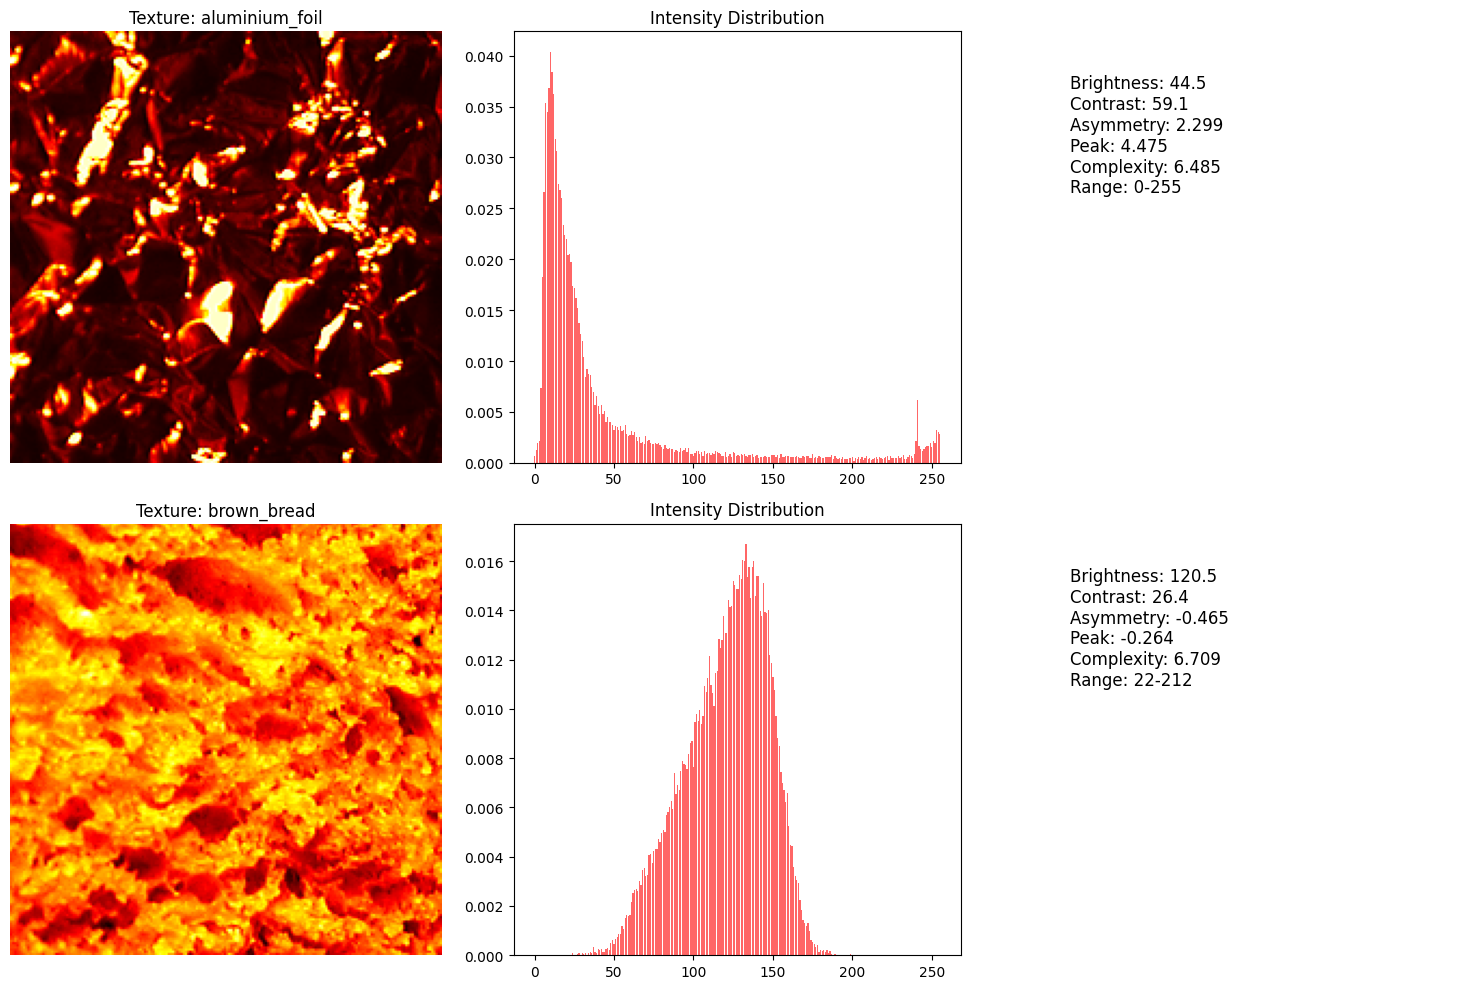

In [37]:
example_plot_texture(image_folder, num_examples=2)

In [38]:
def example_plot_laws(image_folder, num_examples=3):
    texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]
    
    fig, axes = plt.subplots(num_examples, 2, figsize=(12, 4*num_examples))
    
    for i in range(min(num_examples, len(texture_folders))):
        texture_name = texture_folders[i]
        texture_path = os.path.join(image_folder, texture_name)
        
        image_files = [f for f in os.listdir(texture_path)]
        
        image_path = os.path.join(texture_path, image_files[5])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        features, names = laws_texture_features(image)
        
        # 1. Исходное изображение
        axes[i, 0].imshow(image, cmap='cool')
        axes[i, 0].set_title(f'Texture: {texture_name}')
        axes[i, 0].axis('off')
        
        # 2. Топ-5 фильтров как горизонтальная диаграмма
        top_indices = np.argsort(features)[-5:][::-1]
        top_features = [features[idx] for idx in top_indices]
        top_names = [names[idx] for idx in top_indices]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
        bars = axes[i, 1].barh(top_names, top_features, color=colors, alpha=0.8, edgecolor='black')
        
        # Добавляем значения на диаграмму
        for bar, value in zip(bars, top_features):
            axes[i, 1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                          f'{value:.4f}', ha='left', va='center', fontweight='bold')
        
        axes[i, 1].set_title('Top 5 Laws Filters')
        axes[i, 1].set_xlabel('Energy Value')
        axes[i, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

In [45]:
def example_plot_laws(image_folder, num_examples=3):
    texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]
    
    fig, axes = plt.subplots(num_examples, 2, figsize=(12, 4*num_examples))
    
    for i in range(min(num_examples, len(texture_folders))):
        texture_name = texture_folders[i]
        texture_path = os.path.join(image_folder, texture_name)
        
        image_files = [f for f in os.listdir(texture_path)]
        
        image_path = os.path.join(texture_path, image_files[5])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        features, names = laws_texture_features(image)
        
        # 1. Исходное изображение
        axes[i, 0].imshow(image, cmap='cool')
        axes[i, 0].set_title(f'Texture: {texture_name}')
        axes[i, 0].axis('off')
        
        # 2. Топ-5 фильтров как горизонтальная диаграмма
        top_indices = np.argsort(features)[-5:][::-1]
        top_features = [features[idx] for idx in top_indices]
        top_names = [names[idx] for idx in top_indices]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
        bars = axes[i, 1].barh(top_names, top_features, color=colors, alpha=0.8, edgecolor='black')
        
        # Добавляем значения на диаграмму
        for bar, value in zip(bars, top_features):
            axes[i, 1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                          f'{value:.4f}', ha='left', va='center', fontweight='bold')
        
        axes[i, 1].set_title('Top 5 Laws Filters')
        axes[i, 1].set_xlabel('Energy Value')
        axes[i, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

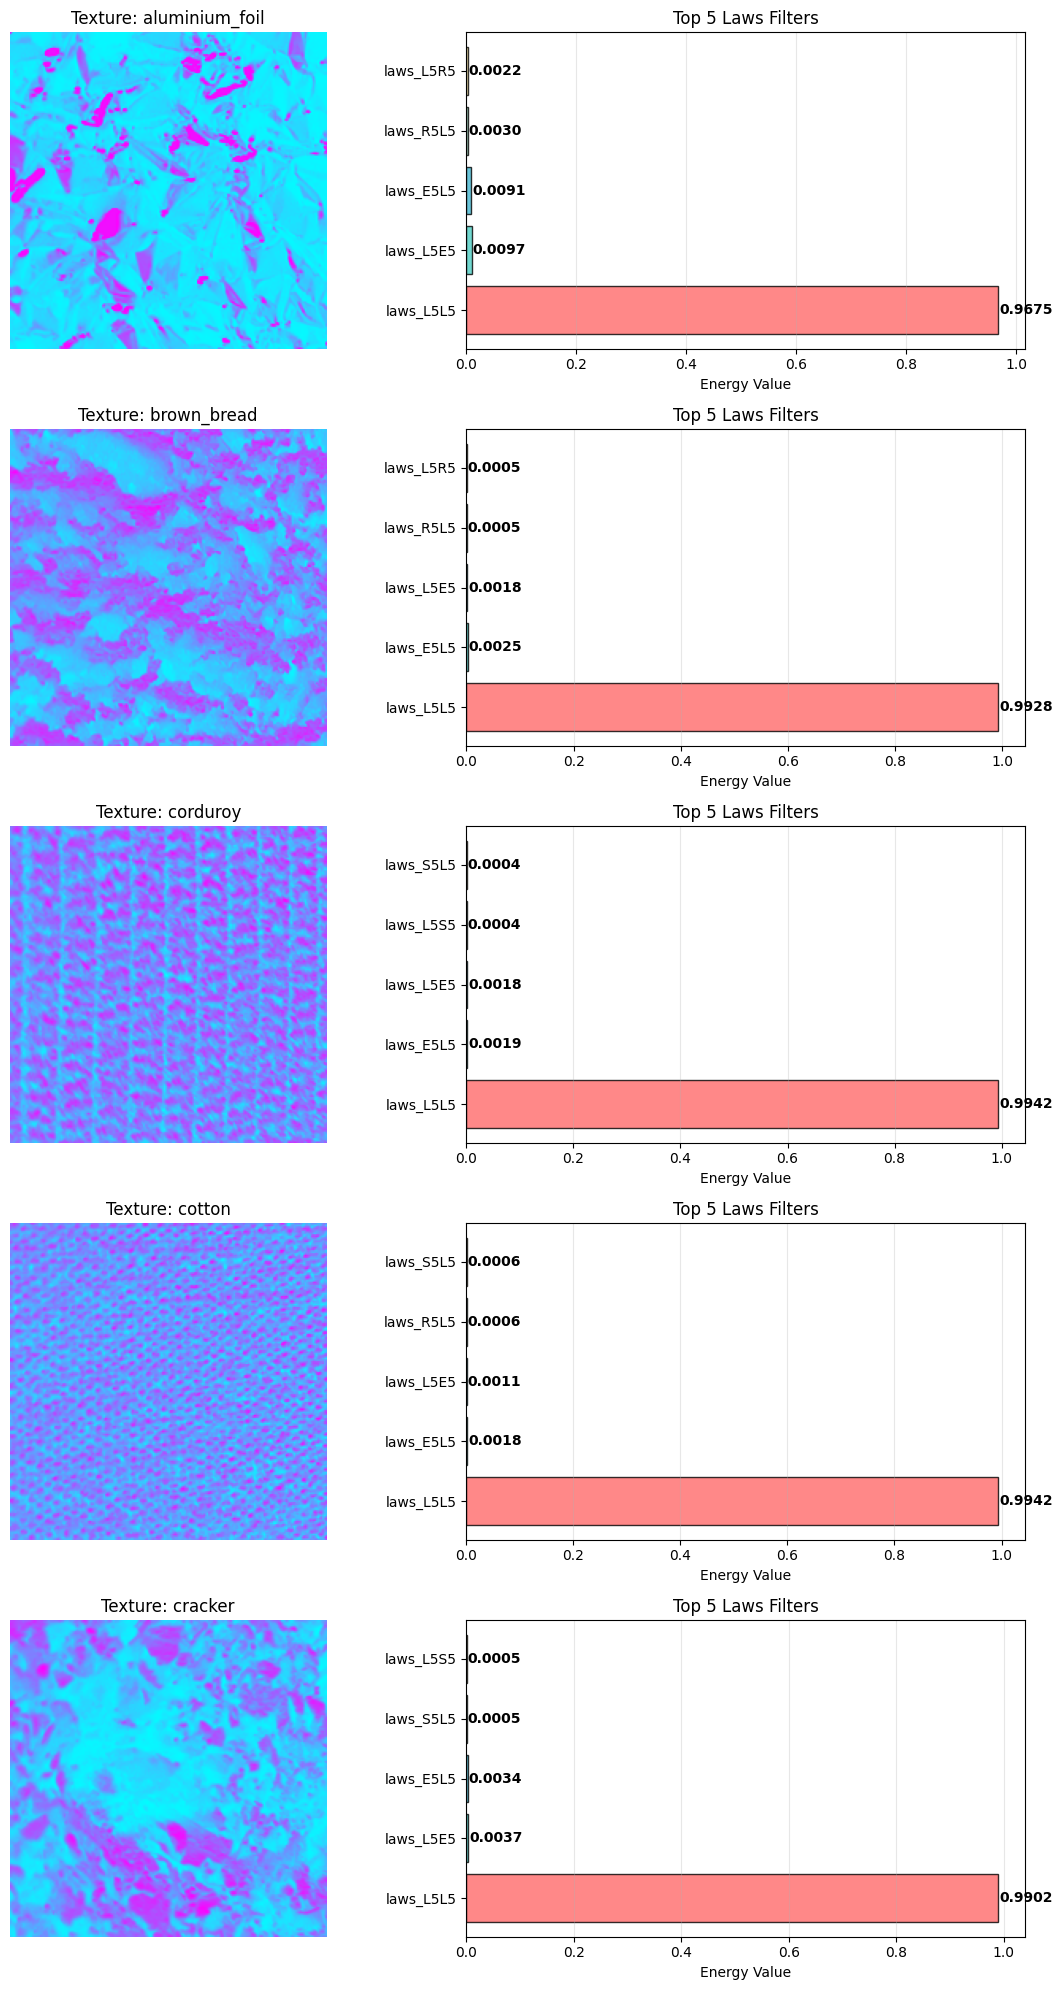

In [46]:
example_plot_laws(image_folder, num_examples=5)

In [11]:
from skimage.feature import graycomatrix, graycoprops
def compute_glcm_features(image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    image = (image // 8).astype(np.uint8)
    
    glcm = graycomatrix(image, distances=distances, angles=angles, 
                       levels=32, symmetric=True, normed=True)
    
    features = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    
    for prop in props:
        feature_val = np.mean(graycoprops(glcm, prop))
        features.append(feature_val)
    
    return np.array(features)

In [51]:
def example_plot_glcm(image_folder, num_examples=3):
    texture_folders = [f for f in os.listdir(image_folder) if os.path.isdir(os.path.join(image_folder, f))]
    
    for i in range(min(num_examples, len(texture_folders))):
        texture_name = texture_folders[i]
        texture_path = os.path.join(image_folder, texture_name)
        
        image_files = [f for f in os.listdir(texture_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(image_files) > 2:
            image_path = os.path.join(texture_path, image_files[2])
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            if image is not None:
                features = compute_glcm_features(image)
                
                plt.figure(figsize=(12, 4))
                
                plt.subplot(1, 2, 1)
                plt.imshow(image, cmap='viridis')
                plt.title(f'Texture: {texture_name}')
                plt.axis('off')
                
                plt.subplot(1, 2, 2)
                
                glcm_names = ['Contrast', 'Homogeneity', 'Energy', 'Correlation', 'Dissimilarity']
                colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF99CC']
                
                # Создаем столбчатую диаграмму
                bars = plt.bar(glcm_names, features[:5], color=colors, alpha=0.8, edgecolor='black')
                
                # Добавляем значения на столбцы
                for bar, value in zip(bars, features[:5]):
                    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                            f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
                
                plt.title('GLCM Texture Features')
                plt.ylabel('Feature Value')
                plt.xticks(rotation=45)
                plt.grid(True, alpha=0.3, axis='y')
                
                plt.tight_layout()
                plt.show()

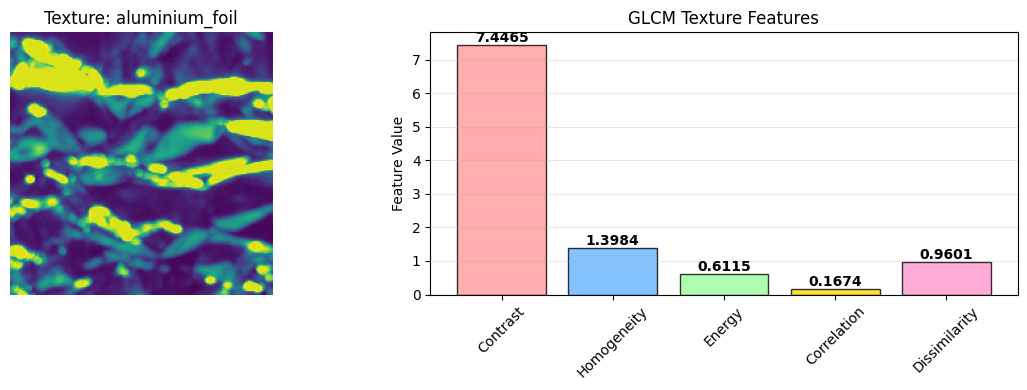

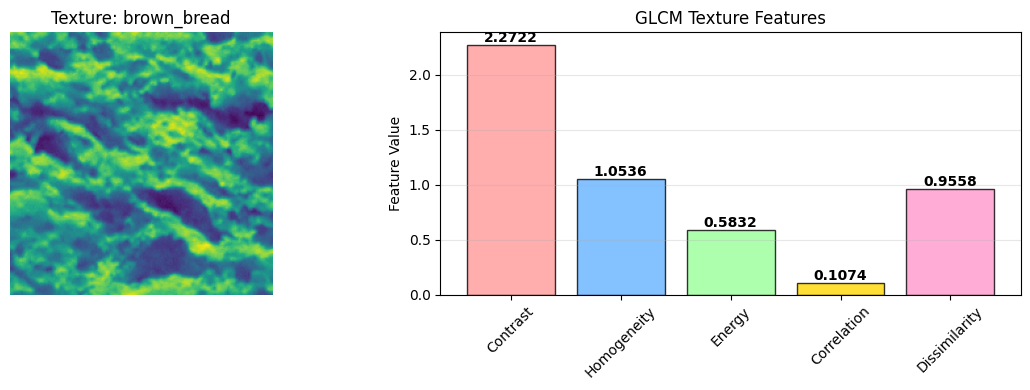

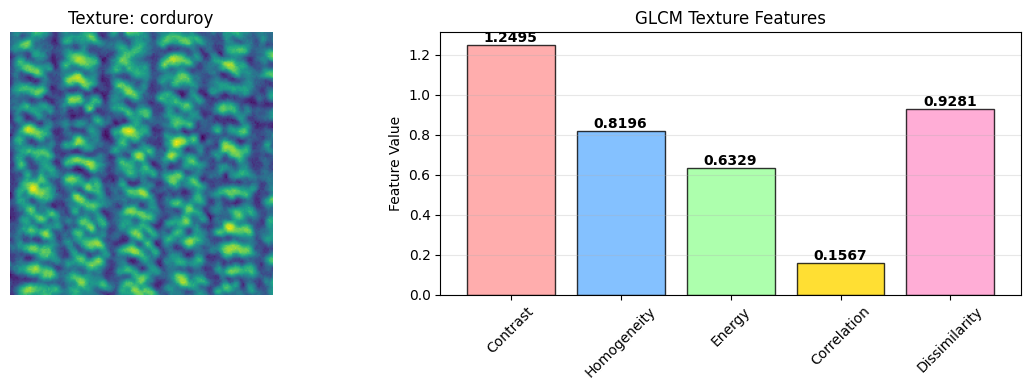

In [52]:
example_plot_glcm(image_folder, num_examples=3)

In [14]:
image_paths = []
for class_folder in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_folder)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_path, file))

print(f"Найдено {len(image_paths)} изображений")

Найдено 810 изображений


In [15]:
X_hist = []  
X_laws = []  
X_glcm = []  
y = []      

for i, path in enumerate(image_paths):
    if i % 50 == 0:
        print(f"Обработано {i}/{len(image_paths)} изображений")
    
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)
    
    hist_features    = extract_histogram_features(image)  
    laws_features, _ = laws_texture_features(image)    
    glcm_features    = compute_glcm_features(image)       
    
    X_hist.append(hist_features)
    X_laws.append(laws_features)
    X_glcm.append(glcm_features)
    
    label = os.path.basename(os.path.dirname(path))
    y.append(label)

X_hist = np.array(X_hist)
X_laws = np.array(X_laws) 
X_glcm = np.array(X_glcm)
y = np.array(y)

print(f"Размер данных: {X_hist.shape}")
print(f"Количество классов: {len(np.unique(y))}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)

methods = {
    'Histogram': X_hist,
    'Laws': X_laws, 
    'GLCM': X_glcm
}

models = {
    'kNN': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
    'SVM': SVC(kernel='rbf', random_state=42),  
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
}

Обработано 0/810 изображений
Обработано 50/810 изображений
Обработано 100/810 изображений
Обработано 150/810 изображений
Обработано 200/810 изображений
Обработано 250/810 изображений
Обработано 300/810 изображений
Обработано 350/810 изображений
Обработано 400/810 изображений
Обработано 450/810 изображений
Обработано 500/810 изображений
Обработано 550/810 изображений
Обработано 600/810 изображений
Обработано 650/810 изображений
Обработано 700/810 изображений
Обработано 750/810 изображений
Обработано 800/810 изображений
Размер данных: (810, 10)
Количество классов: 10


In [55]:
trained_models = {}

for method_name, X in methods.items():
    print(f"\n МЕТОД: {method_name.upper()}")
    print("=" * 40)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    method_models = {}
    
    for model_name, model_template in models.items():
        if model_name == 'kNN':
            model = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
        elif model_name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)
        elif model_name == 'DecisionTree':
            model = DecisionTreeClassifier(random_state=42, max_depth=10)
        
        if model_name == 'SVM':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            method_models[model_name] = (model, scaler)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            method_models[model_name] = model
        
        accuracy = np.mean(y_pred == y_test)
        print(f" {model_name}:")
        print(f"   Точность: {accuracy:.1%}")
        print(f"   Отчет:\n{classification_report(y_test, y_pred, target_names=le.classes_)}")
    
    trained_models[method_name] = method_models


 МЕТОД: HISTOGRAM
 kNN:
   Точность: 74.4%
   Отчет:
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_bread       0.90      0.95      0.93        20
      corduroy       0.58      0.70      0.64        20
        cotton       0.55      0.52      0.54        21
       cracker       0.83      0.71      0.77        21
         linen       0.76      0.65      0.70        20
   orange_peel       0.94      0.76      0.84        21
     sandpaper       0.39      0.35      0.37        20
        sponge       0.64      0.80      0.71        20
     styrofoam       0.91      1.00      0.95        20

      accuracy                           0.74       203
     macro avg       0.75      0.74      0.74       203
  weighted avg       0.75      0.74      0.74       203

 SVM:
   Точность: 83.7%
   Отчет:
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_br

In [17]:
selected_models = {
    'Histogram_kNN': trained_models['Histogram']['kNN'],  
    'Laws_Tree': trained_models['Laws']['DecisionTree'],                      
    'Laws_SVM': trained_models['Laws']['SVM']                                     
}

In [18]:
def segment_sandwich(model_info, model_name, image_path, patch_size=32, step=16, n_classes=4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    
    h, w = image.shape
    seg_map = np.zeros((h, w), dtype=np.uint8)

    all_predictions = []
    positions = []
    
    for y in range(0, h - patch_size + 1, step):
        for x in range(0, w - patch_size + 1, step):
            patch = image[y:y+patch_size, x:x+patch_size]
            
            if 'Histogram' in model_name:
                features = extract_histogram_features(patch)
            elif 'Laws' in model_name:
                features, _ = laws_texture_features(patch)
            elif 'GLCM' in model_name:
                features = compute_glcm_features(patch)
            
            if isinstance(model_info, tuple):  
                model, scaler = model_info
                features_scaled = scaler.transform(features.reshape(1, -1))
                pred_class = model.predict(features_scaled)[0]
            else:  
                model = model_info
                pred_class = model.predict(features.reshape(1, -1))[0]
            
            seg_map[y:y+patch_size, x:x+patch_size] = pred_class
            all_predictions.append(pred_class)
            positions.append((y, x))

    unique, counts = np.unique(all_predictions, return_counts=True)
    
    top_classes = unique[np.argsort(counts)[-n_classes:]]
    
    seg_map_filtered = np.zeros_like(seg_map)
    
    for i, class_id in enumerate(top_classes):
        seg_map_filtered[seg_map == class_id] = i
    
    mask_not_in_top = ~np.isin(seg_map, top_classes)
    if np.any(mask_not_in_top):
        seg_map_filtered[mask_not_in_top] = 1 
    
    print(f"Уникальные классы после фильтрации: {np.unique(seg_map_filtered)}")
    
    return seg_map_filtered

Обрабатываем: Histogram_kNN
Уникальные классы после фильтрации: [0 1 2 3]
Успешно
Обрабатываем: Laws_Tree
Уникальные классы после фильтрации: [0 1 2 3]
Успешно
Обрабатываем: Laws_SVM
Уникальные классы после фильтрации: [0 1 2 3]
Успешно


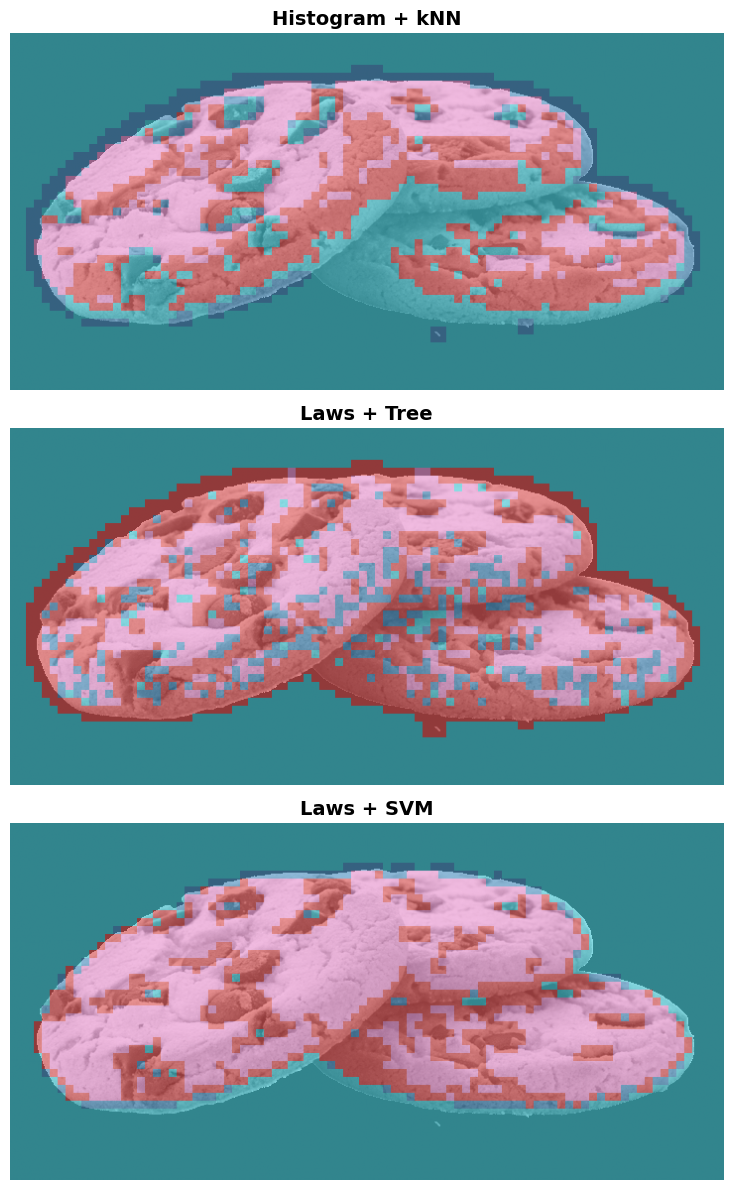

In [56]:
image_path = "chok.png"
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_img is not None:
    seg_maps = []
    model_names = []
    
    for model_name, model_info in selected_models.items():
        print(f"Обрабатываем: {model_name}")
        
        seg_result = segment_sandwich(model_info, model_name, image_path, patch_size=16, step=8)
        
        if seg_result is not None:
            seg_maps.append(seg_result)
            model_names.append(model_name)
            print(f"Успешно")
        else:
            print(f"Ошибка")
    
    if seg_maps:
        fig, axes = plt.subplots(3, 1, figsize=(8, 12))  
        
        for i, (seg_map, model_name) in enumerate(zip(seg_maps, model_names)):
            if 'Histogram' in model_name:
                method = 'Histogram'
                model_type = 'kNN'
            elif 'Laws' in model_name:
                method = 'Laws'
                if 'Tree' in model_name:
                    model_type = 'Tree'
                else:
                    model_type = 'SVM'
            
            axes[i].imshow(original_img, cmap='gray', alpha=0.7)
            axes[i].imshow(seg_map, cmap='tab10', alpha=0.5)
            axes[i].set_title(f'{method} + {model_type}', fontsize=14, fontweight='bold')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

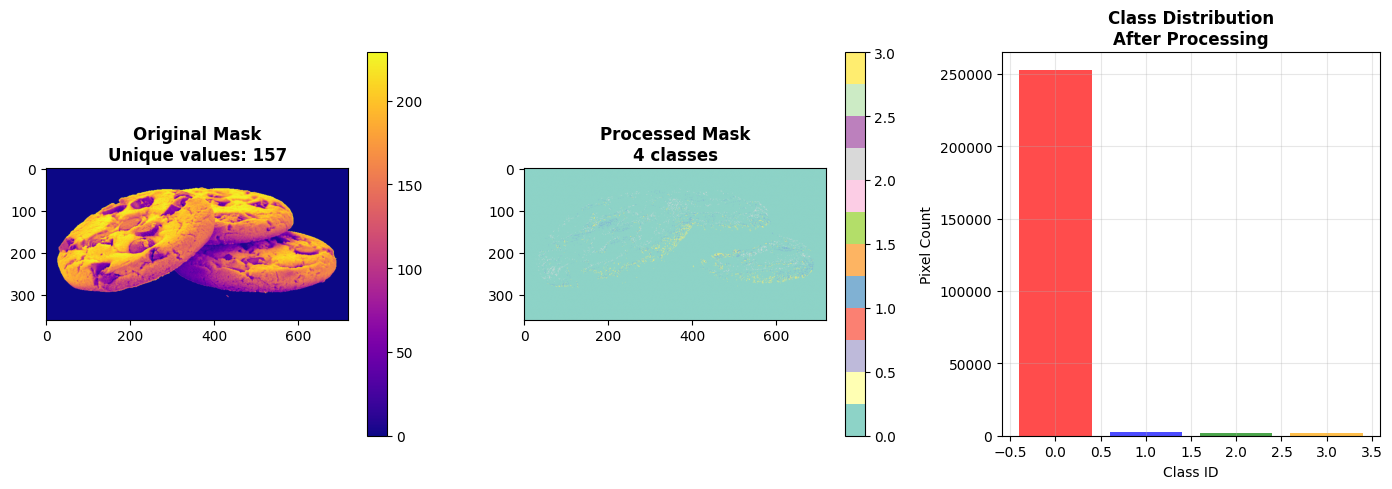

In [57]:
def keep_top_colors(mask, n_colors=4):  
    unique, counts = np.unique(mask, return_counts=True)
    
    sorted_indices = np.argsort(-counts)
    top_colors = unique[sorted_indices[:n_colors]]
    
    result = np.zeros_like(mask)
    
    for new_value, old_value in enumerate(top_colors):
        result[mask == old_value] = new_value
    
    return result

manual_mask_path = "chok.png"
manual_mask = cv2.imread(manual_mask_path, cv2.IMREAD_GRAYSCALE)
fixed_manual_mask = keep_top_colors(manual_mask, n_colors=4)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(manual_mask, cmap='plasma')
plt.title(f'Original Mask\nUnique values: {len(np.unique(manual_mask))}', fontweight='bold')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(fixed_manual_mask, cmap='Set3')
plt.title('Processed Mask\n4 classes', fontweight='bold')
plt.colorbar()

plt.subplot(1, 3, 3)
# Добавим гистограмму распределения классов
unique_old, counts_old = np.unique(manual_mask, return_counts=True)
unique_new, counts_new = np.unique(fixed_manual_mask, return_counts=True)

plt.bar(unique_new, counts_new, color=['red', 'blue', 'green', 'orange'], alpha=0.7)
plt.title('Class Distribution\nAfter Processing', fontweight='bold')
plt.xlabel('Class ID')
plt.ylabel('Pixel Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Запускаем сегментацию...
Уникальные классы после фильтрации: [0 1 2 3]
Предсказание: (360, 720)
Уникальные классы в предсказании: [0 1 2 3]
Классы в ручной разметке: [0 1 2 3]
Классы в предсказании: [0 1 2 3]

Точность: 49.9%
IoU по классам:
   Класс 0: 0.504
   Класс 1: 0.020
   Класс 2: 0.009
   Класс 3: 0.004


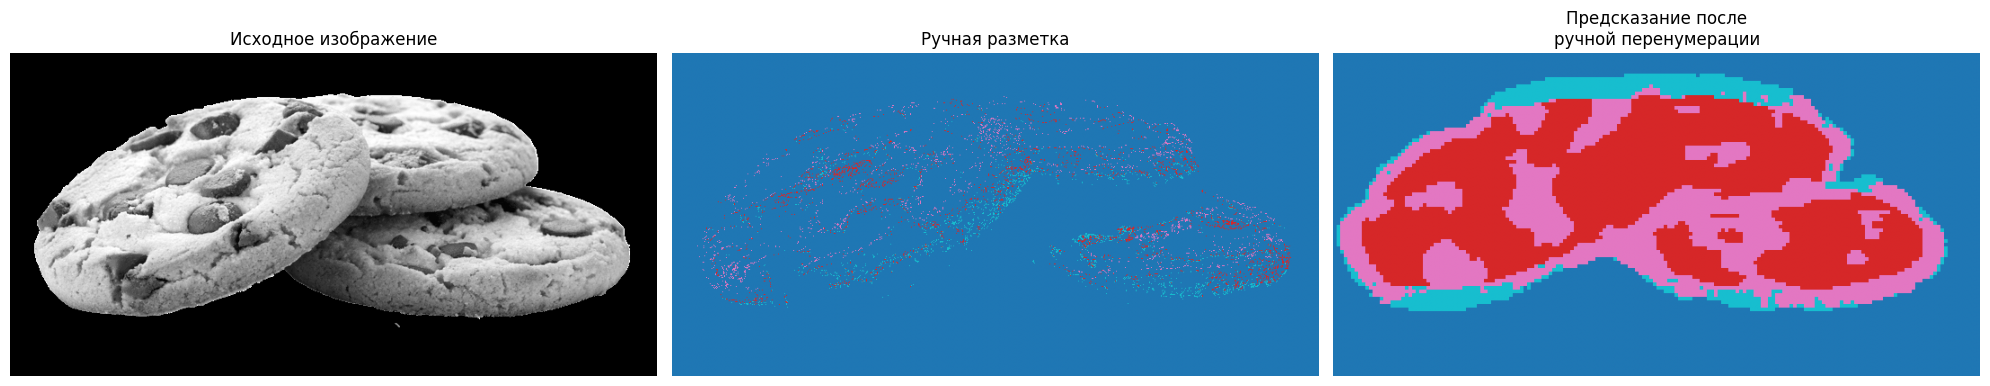

Итог: 49.9% правильных пикселей


In [59]:
from sklearn.metrics import accuracy_score, jaccard_score
def compare_simple(manual_mask, predicted_mask, model_name, original_img):
    
    predicted_resized = predicted_mask
    
    manual_classes = np.unique(manual_mask)
    pred_classes = np.unique(predicted_resized)
    
    print(f"Классы в ручной разметке: {manual_classes}")
    print(f"Классы в предсказании: {pred_classes}")
    
    class_mapping = {
        0: 3,  
        1: 2,  
        2: 1,    
        3: 0   
    }
    
    pred_mapped = predicted_resized.copy()
    for pred_class, manual_class in class_mapping.items():
        pred_mapped[predicted_resized == pred_class] = manual_class
    
    accuracy = accuracy_score(manual_mask.flatten(), pred_mapped.flatten())
    
    print(f"\nТочность: {accuracy:.1%}")
    print(f"IoU по классам:")
    
    for class_id in manual_classes:
        iou = jaccard_score(manual_mask.flatten(), pred_mapped.flatten(), 
                          average=None, labels=[class_id])[0]
        print(f"   Класс {class_id}: {iou:.3f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')
    
    axes[1].imshow(manual_mask, cmap='tab10')
    axes[1].set_title('Ручная разметка')
    axes[1].axis('off')
    
    axes[2].imshow(pred_mapped, cmap='tab10')
    axes[2].set_title(f'Предсказание после\nручной перенумерации')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy

image_path = "chok.png"
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

model_name = 'Laws_SVM'
model_info = selected_models[model_name]

print("Запускаем сегментацию...")
predicted_mask = segment_sandwich(
    model_info, model_name, image_path,
    patch_size=32, step=4
)

print(f"Предсказание: {predicted_mask.shape}")
print(f"Уникальные классы в предсказании: {np.unique(predicted_mask)}")

if fixed_manual_mask is not None and predicted_mask is not None and original_img is not None:
    accuracy = compare_simple(fixed_manual_mask, predicted_mask, model_name, original_img)
    print(f"Итог: {accuracy*100:.1f}% правильных пикселей")